# Projet #3 - Prédiction du Churn Client
## Notebook 1 - Analyse, qualité et préparation des données

Ce notebook répond au **premier livrable** du brief : analyser la qualité du jeu de données, produire une analyse statistique descriptive avec visualisations, puis définir une procédure de nettoyage pour rendre les données exploitables par un processus d'apprentissage.

**Objectifs :**
- comprendre la structure du dataset Telco Customer Churn ;
- identifier valeurs manquantes, incohérences et doublons ;
- comparer les profils des clients qui restent et de ceux qui churnent ;
- nettoyer `TotalCharges` et préparer la cible ;
- produire un jeu de données propre pour le notebook de modélisation.

> Chaque ligne représente un client. La cible `Churn` indique si le client a quitté l'entreprise le mois précédent.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")

# Retrouver le projet depuis sa racine ou depuis le dossier notebooks.
# Les notebooks importent le script pour utiliser exactement les mêmes règles.
import sys
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src/train.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src/train.py").exists():
    raise FileNotFoundError("Ouvrez le notebook depuis le projet ou son dossier notebooks.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.train import DATA_PATH, load_data, clean_data, split_features_target

# Lire le même fichier brut que le script.
df = load_data()
print(f"Fichier chargé : {DATA_PATH}")
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head()

Fichier chargé : /Users/sambalarimiscky/CascadeProjects/Pr-dictionduChurnClientavecdesMod-lesdeMachineLearning-rimiscky-vibrant-pasteur-y3zb9v/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
Dimensions : 7,043 lignes × 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Qualité des données

On vérifie la structure, les types, les doublons, les valeurs manquantes et les valeurs atypiques. Une attention particulière est portée à `TotalCharges`, qui est importée comme texte alors qu'elle représente un montant numérique.


In [2]:
quality = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "valeurs_manquantes": df.isna().sum(),
    "nb_uniques": df.nunique(dropna=False)
})
quality

,type,valeurs_manquantes,nb_uniques
customerID,str,0,7043
gender,str,0,2
SeniorCitizen,int64,0,2
Partner,str,0,2
Dependents,str,0,2
tenure,int64,0,73
PhoneService,str,0,2
MultipleLines,str,0,3
InternetService,str,0,3
OnlineSecurity,str,0,3


In [3]:
print("Doublons exacts :", df.duplicated().sum())
print("Identifiants clients dupliqués :", df["customerID"].duplicated().sum())

blank_total = df["TotalCharges"].astype(str).str.strip().eq("")
print("TotalCharges vides/non renseignés :", int(blank_total.sum()))

print("\nRépartition de la cible :")
display(df["Churn"].value_counts())
display((df["Churn"].value_counts(normalize=True) * 100).round(2).rename("pourcentage"))

Doublons exacts : 0
Identifiants clients dupliqués : 0
TotalCharges vides/non renseignés : 11

Répartition de la cible :


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: pourcentage, dtype: float64

### Interprétation qualité

- `customerID` est un identifiant technique : il ne doit pas être utilisé comme variable prédictive.
- `TotalCharges` contient quelques chaînes vides. Elles deviennent des `NaN` lors de la conversion numérique.
- Les lignes concernées correspondent typiquement à des clients avec une ancienneté très faible / nulle ; on choisit ici une **imputation médiane** dans le pipeline ML afin de conserver ces clients.
- La cible est déséquilibrée : le churn représente environ un quart des clients. L'accuracy seule serait donc insuffisante ; on suivra aussi précision, rappel, F1 et ROC-AUC.


In [4]:
# Nettoyage commun : doublons exacts avec identifiant, puis conversion de TotalCharges.
# Deux clients distincts ayant le même profil sont conservés.
df_clean = clean_data(df)

print("NaN après conversion de TotalCharges :", df_clean["TotalCharges"].isna().sum())
display(df_clean.loc[df_clean["TotalCharges"].isna(),
                     ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head(15))

NaN après conversion de TotalCharges : 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


## 2. Statistiques descriptives


In [5]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


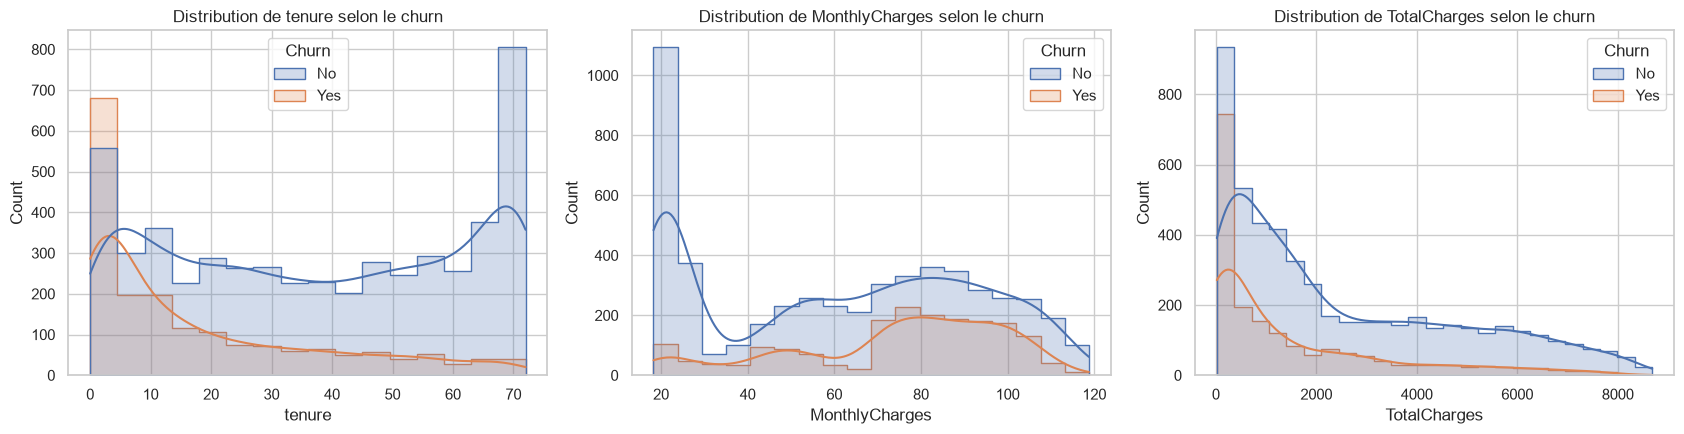

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df_clean, x=col, hue="Churn", kde=True, element="step", ax=ax)
    ax.set_title(f"Distribution de {col} selon le churn")
plt.tight_layout()
plt.show()

### Lecture

Ces distributions permettent d'observer si les clients qui churnent ont une ancienneté ou des niveaux de facturation différents de ceux qui restent. L'objectif n'est pas de conclure à une causalité, mais d'identifier des variables potentiellement prédictives.


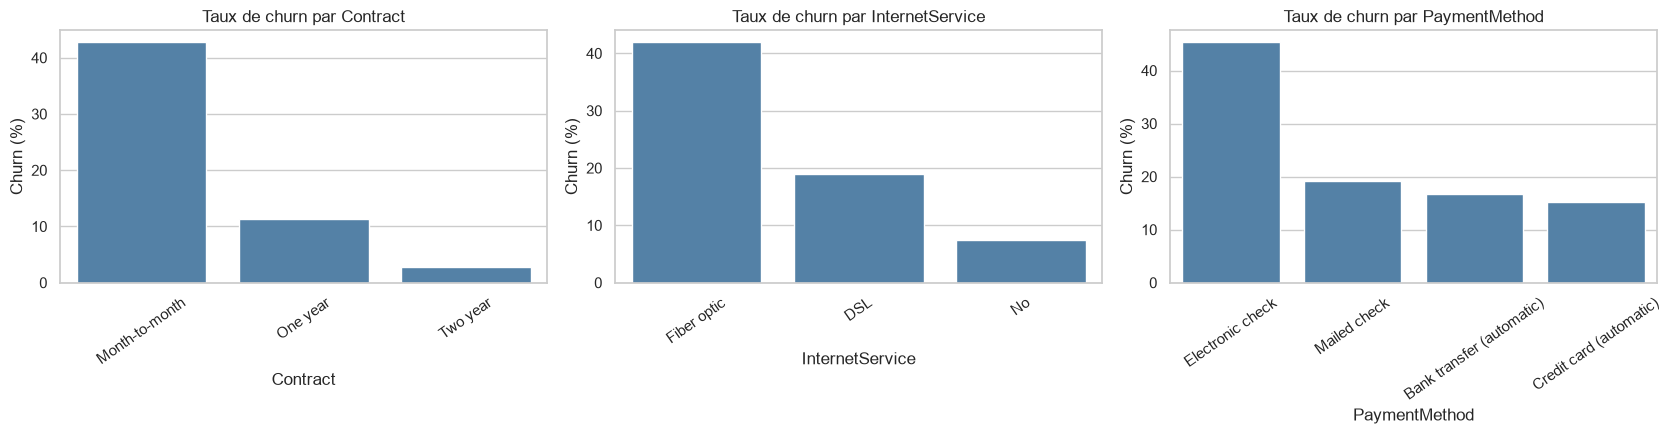

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    rate = (df_clean.groupby(col)["Churn"]
            .apply(lambda s: (s == "Yes").mean())
            .sort_values(ascending=False)
            .mul(100)
            .rename("churn_rate")
            .reset_index())
    sns.barplot(data=rate, x=col, y="churn_rate", ax=ax, color="steelblue")
    ax.set_title(f"Taux de churn par {col}")
    ax.set_ylabel("Churn (%)")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

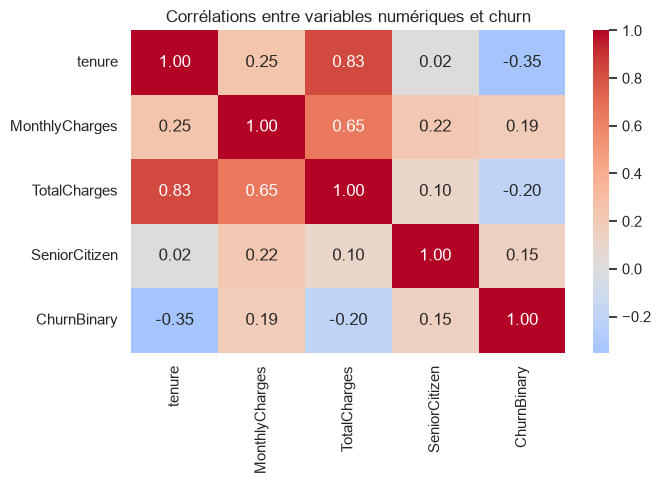

ChurnBinary       1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: ChurnBinary, dtype: float64

In [8]:
churn_numeric = df_clean.assign(ChurnBinary=(df_clean["Churn"] == "Yes").astype(int))
corr = churn_numeric[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "ChurnBinary"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations entre variables numériques et churn")
plt.tight_layout()
plt.show()
corr["ChurnBinary"].sort_values(ascending=False)

## 3. Analyse ciblée des caractéristiques

On examine quelques variables métier importantes : type de contrat, service Internet, support technique, sécurité en ligne et ancienneté. Les écarts observés guideront ensuite l'interprétation des modèles.


In [9]:
categorical_focus = ["Contract", "InternetService", "TechSupport", "OnlineSecurity", "PaperlessBilling"]

for col in categorical_focus:
    table = pd.crosstab(df_clean[col], df_clean["Churn"], normalize="index").mul(100).round(1)
    print(f"\n--- {col} ---")
    display(table)


--- Contract ---


Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8



--- InternetService ---


Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4



--- TechSupport ---


Churn,No,Yes
TechSupport,,
No,58.4,41.6
No internet service,92.6,7.4
Yes,84.8,15.2



--- OnlineSecurity ---


Churn,No,Yes
OnlineSecurity,,
No,58.2,41.8
No internet service,92.6,7.4
Yes,85.4,14.6



--- PaperlessBilling ---


Churn,No,Yes
PaperlessBilling,,
No,83.7,16.3
Yes,66.4,33.6


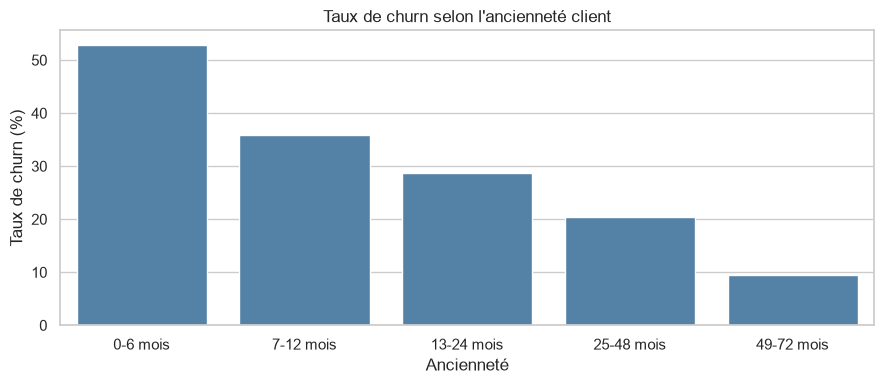

In [10]:
# Churn selon des classes d'ancienneté
bins = [-1, 6, 12, 24, 48, 72]
labels = ["0-6 mois", "7-12 mois", "13-24 mois", "25-48 mois", "49-72 mois"]
df_clean["tenure_group"] = pd.cut(df_clean["tenure"], bins=bins, labels=labels)

tenure_churn = (df_clean.groupby("tenure_group", observed=False)["Churn"]
                .apply(lambda s: (s == "Yes").mean())
                .mul(100)
                .rename("churn_rate")
                .reset_index())

plt.figure(figsize=(9, 4))
sns.barplot(data=tenure_churn, x="tenure_group", y="churn_rate", color="steelblue")
plt.ylabel("Taux de churn (%)")
plt.xlabel("Ancienneté")
plt.title("Taux de churn selon l'ancienneté client")
plt.tight_layout()
plt.show()

## 4. Procédure de nettoyage retenue

1. Conserver une copie du dataset brut.
2. Convertir `TotalCharges` en numérique avec `errors="coerce"`.
3. Retirer `customerID` des variables d'apprentissage.
4. Transformer `Churn` en cible binaire (`Yes` → 1, `No` → 0).
5. Ne pas imputer/encoder avant la séparation train/test : ces opérations seront placées dans un `Pipeline` scikit-learn afin d'éviter les fuites de données.
6. Imputer les variables numériques par médiane.
7. Encoder les catégories avec `OneHotEncoder(handle_unknown="ignore")`.
8. Standardiser les variables numériques pour la régression logistique.

Le groupe d'ancienneté créé ci-dessus sert uniquement à l'EDA et n'est pas conservé comme variable d'entrée, car `tenure` contient déjà l'information originale.


In [11]:
# Préparation d'un fichier propre pour le notebook 2
prepared = df_clean.drop(columns=["tenure_group"]).copy()
# Réutiliser la validation de la cible du script avant de sauvegarder.
_, prepared["Churn"] = split_features_target(prepared)

OUTPUT_DIR = PROJECT_ROOT / "data/processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = OUTPUT_DIR / "telco_churn_clean.csv"
prepared.to_csv(OUTPUT_PATH, index=False)

print(f"Jeu nettoyé enregistré : {OUTPUT_PATH}")
print("Dimensions :", prepared.shape)
print("NaN TotalCharges conservés pour imputation dans le pipeline :", prepared["TotalCharges"].isna().sum())
prepared.head()

Jeu nettoyé enregistré : /Users/sambalarimiscky/CascadeProjects/Pr-dictionduChurnClientavecdesMod-lesdeMachineLearning-rimiscky-vibrant-pasteur-y3zb9v/data/processed/telco_churn_clean.csv
Dimensions : (7043, 21)
NaN TotalCharges conservés pour imputation dans le pipeline : 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 5. Conclusions de l'EDA

Le dataset est globalement exploitable mais nécessite une correction de type pour `TotalCharges`. La cible est déséquilibrée, ce qui impose d'évaluer les modèles avec plusieurs métriques.

Les analyses descriptives suggèrent que l'ancienneté, le type de contrat, certains services Internet et le niveau de facturation sont liés au churn. Ces observations seront vérifiées dans le notebook suivant à l'aide de modèles supervisés et de l'importance des caractéristiques.
